In [46]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pickle
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / 'src'))
from src.perturbation.models.classifiers.rf_classifier import RFClassifier
from src.perturbation.models.regressors.rf_regressor import RFRegressor
print(ROOT)
from src.loading_data.load_data import get_clean_2022

c:\Users\fergu\Documents\GitHub\london_sport2


In [17]:
rfreg_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\src\perturbation\models\saved_models\RFRegressor.sav'
rfclas_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\src\perturbation\models\saved_models\RFClassifier.sav'
with open(rfreg_path, 'rb') as file:
    rf_regressor = pickle.load(file)
with open(rfclas_path, 'rb') as file:
    rf_classifier = pickle.load(file)


In [18]:
rf_regressor.get_rmse()

np.float64(2.3714097020451015)

In [19]:
(rf_regressor.Y_train == 0).mean()

np.float64(0.1662861491628615)

<Axes: >

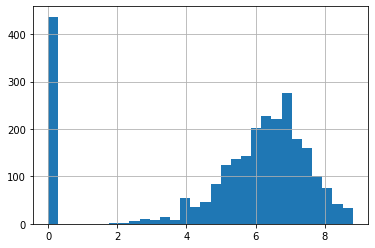

In [20]:
rf_regressor.Y_train.hist(bins=30)

In [44]:
np.expm1(2.3)

np.float64(8.974182454814718)

In [31]:
Y = np.expm1(rf_regressor.Y_train)
Y.describe()

count    2628.000000
mean      820.764365
std      1059.549181
min         0.000000
25%       120.000000
50%       477.500000
75%      1080.000000
max      6720.000000
Name: MEMS7_ALL, dtype: float64

In [22]:
maximum = 6720
over_max = (Y > maximum).mean() * 100
over_max

np.float64(0.3424657534246575)

<Axes: >

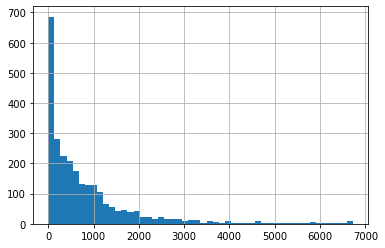

In [23]:
Y_capped = Y.clip(upper=maximum)
Y_capped.hist(bins=50)

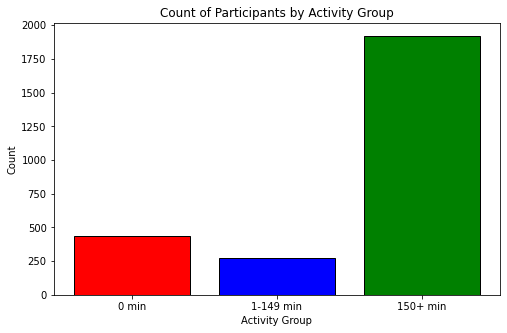

In [ ]:
counts = [
    (Y_capped == 0).sum(),
    ((Y_capped > 0) & (Y_capped < 150)).sum(),
    (Y_capped >= 150).sum()
]

labels = ["0 min", "1-149 min", "150+ min"]
colors = ["red", "blue", "green"]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=colors, edgecolor="black")

plt.xlabel("Activity Group")
plt.ylabel("Count")
plt.title("Count of Participants by Activity Group")
plt.show()

In [25]:
Y_train_log = np.log1p(Y_capped)

<Axes: >

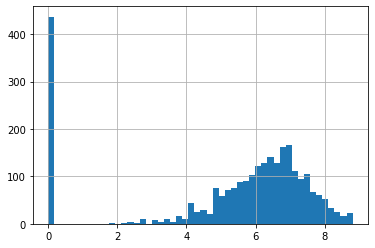

In [26]:
Y_train_log.hist(bins=50)

In [27]:
rf_classifier.get_roc_auc()

0.7027681045751634

In [28]:
rf_classifier.get_f1()

0.8489263803680982

In [29]:
Y_class = rf_classifier.Y_train

In [30]:
Y_class.value_counts()

active
True     1921
False     707
Name: count, dtype: int64

In [47]:
df = get_clean_2022()

['Gend3', 'Disab2_POP', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'Child4', 'WorkStat8', 'HHLiv9', 'serial', 'year', 'LCA_Class', 'MEMS7_ALL']
Data loaded with zero missing values.
Loaded primary frame...
Loaded secondary frame...
Merged Frames.
Dropped NAN values


In [48]:
df.columns

Index(['serial', 'year', 'LCA_Class', 'Age9', 'Gend3', 'Eth7', 'Disab2_POP',
       'Educ6', 'NSSEC5', 'IMD10', 'WorkStat8', 'Child4', 'HHLiv9',
       'MEMS7_ALL', 'active', 'Motiva_POP', 'motivd_POP', 'inclus_a',
       'inclus_b', 'inclus_c', 'anxious', 'comm1', 'comm2', 'happy', 'indev',
       'indevtry', 'lone', 'worthw'],
      dtype='str')